In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
np.sort(df['age'].unique())

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64])

In [65]:
df['age'].value_counts(normalize=True).head(10) * 100

age
18    5.156951
19    5.082212
46    2.167414
52    2.167414
50    2.167414
47    2.167414
48    2.167414
51    2.167414
45    2.167414
20    2.167414
Name: proportion, dtype: float64

### males vs females differ in smoking behavior - Percentage Comparison

In [13]:
df['sex'].value_counts(normalize=True) * 100


sex
male      50.523169
female    49.476831
Name: proportion, dtype: float64

In [14]:
pd.crosstab(df['sex'], df['smoker'], normalize='index') * 100

smoker,no,yes
sex,,
female,82.628399,17.371601
male,76.479290,23.520710


In [15]:
df.groupby(['sex','smoker'])['charges'].mean().reset_index()

,sex,smoker,charges
0,female,no,8762.297300
1,female,yes,30678.996276
2,male,no,8087.204731
3,male,yes,33042.005975


### The analysis shows that smoking status has a dominant impact on insurance charges, increasing costs by nearly 3–4 times for both genders. Gender differences are relatively minor, although male smokers exhibit slightly higher charges than female smokers. Overall, smoking is the primary driver of insurance cost, while gender plays a secondary role.

In [16]:
np.sort(df['children'].unique())

array([0, 1, 2, 3, 4, 5])

In [17]:
df['children'].value_counts(normalize=True) * 100


children
0    42.899851
1    24.215247
2    17.937220
3    11.733931
4     1.868460
5     1.345291
Name: proportion, dtype: float64

In [18]:
df['smoker'].value_counts(normalize=True) * 100


smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64

In [19]:
df['region'].value_counts(normalize=True) * 100


region
southeast    27.204783
southwest    24.289985
northwest    24.289985
northeast    24.215247
Name: proportion, dtype: float64

In [20]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [21]:
np.sort(df['charges'].unique())

array([ 1121.8739 ,  1131.5066 ,  1135.9407 , ..., 60021.39897,
       62592.87309, 63770.42801], shape=(1337,))

In [22]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [23]:
import pandas as pd

# Load dataset
df = pd.read_csv("insurance.csv")

# Convert categorical features to numerical
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded = df_encoded.astype(int)

print(df_encoded.head())

   age  bmi  children  charges  sex_male  smoker_yes  region_northwest  \
0   19   27         0    16884         0           1                 0   
1   18   33         1     1725         1           0                 0   
2   28   33         3     4449         1           0                 0   
3   33   22         0    21984         1           0                 1   
4   32   28         0     3866         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [24]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


In [25]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Visulation

## Data Distribution

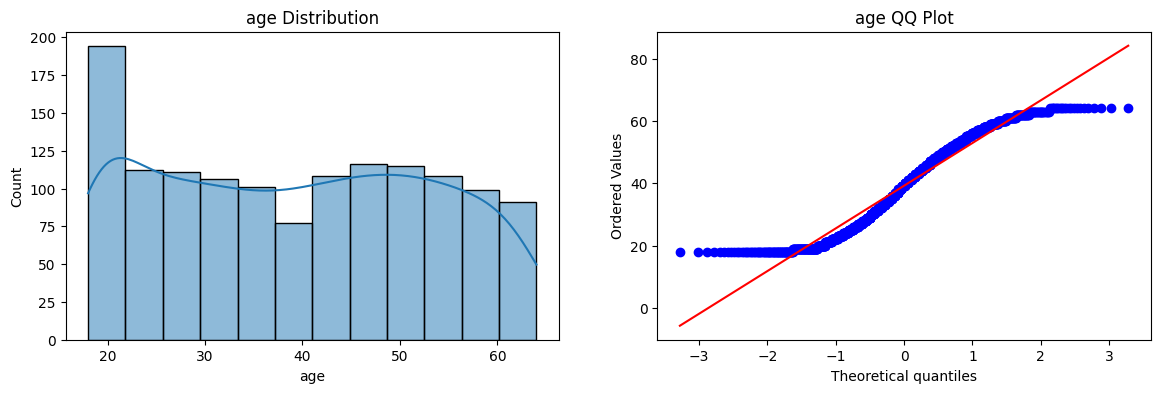

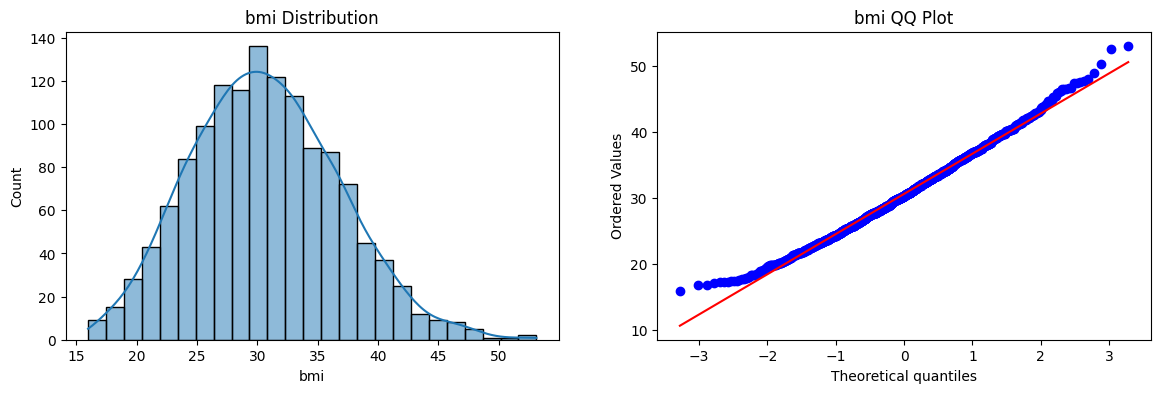

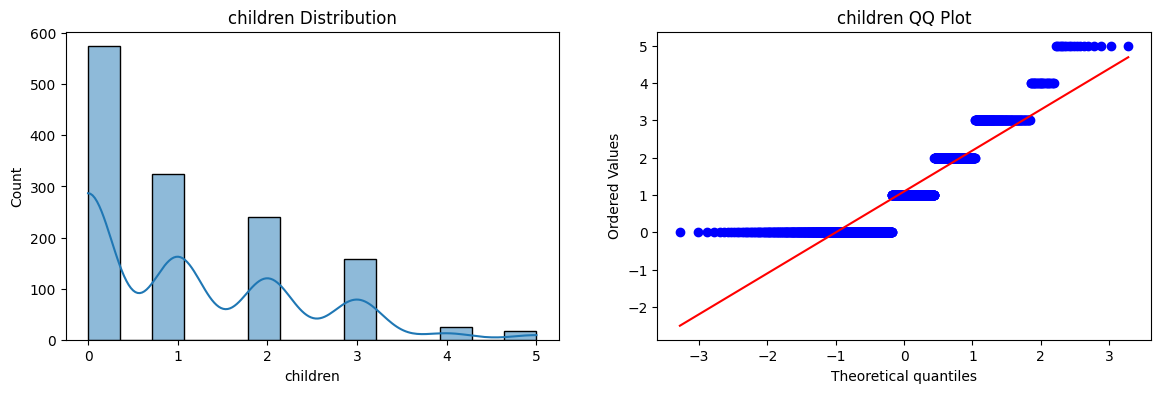

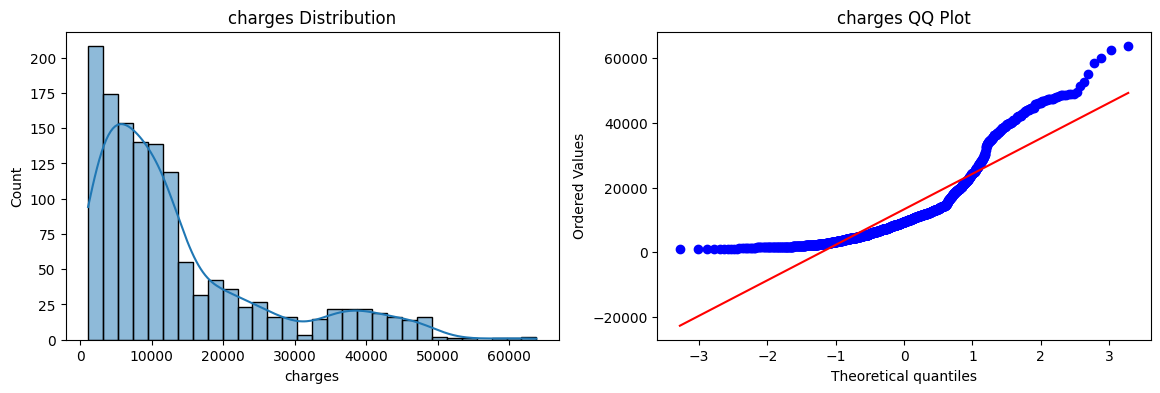

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

num_cols = ['age','bmi','children','charges']

for col in num_cols:
    
    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    sns.histplot(df[col], kde=True)
    plt.title(col + ' Distribution')
    
    plt.subplot(122)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(col + ' QQ Plot')
    
    plt.show()

## Pairplot with Smoker Separation

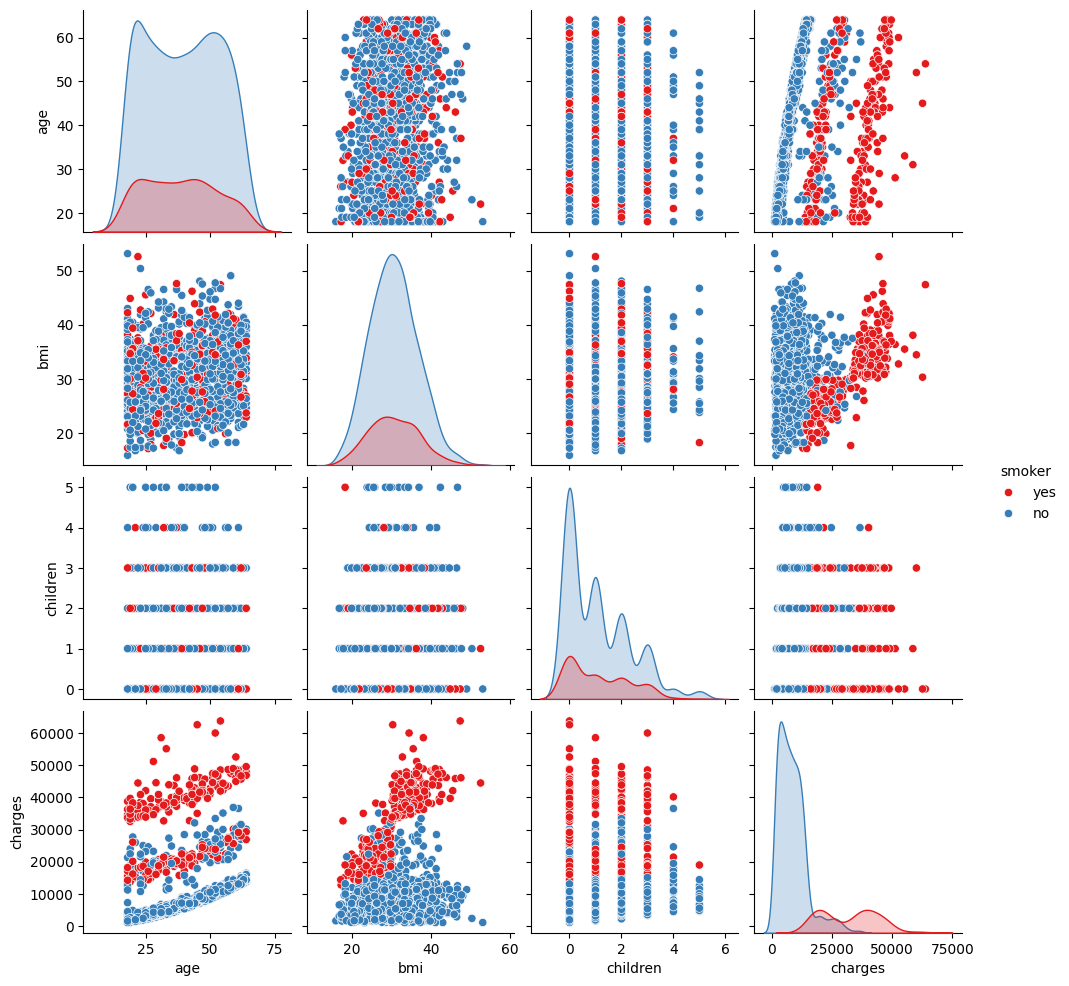

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the most relevant numerical features
cols = ['age', 'bmi', 'children', 'charges', 'smoker']

sns.pairplot(
    df[cols],
    hue='smoker',
    diag_kind='kde',
    palette='Set1'
)

plt.show()

## 8 Relationship Between Age and Charges

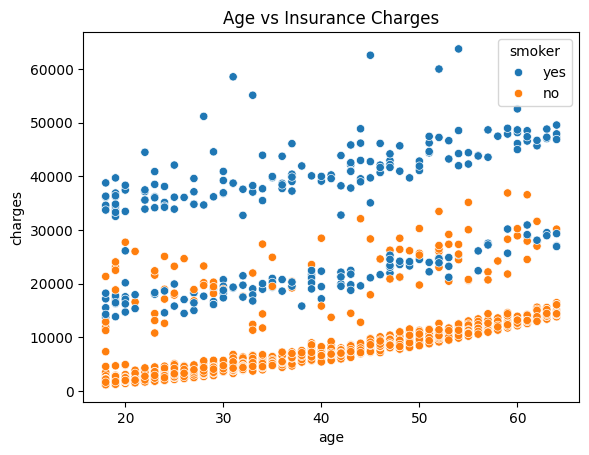

In [28]:
sns.scatterplot(
    x='age',
    y='charges',
    hue='smoker',
    data=df
)

plt.title("Age vs Insurance Charges")
plt.show()

### BMI vs Charges

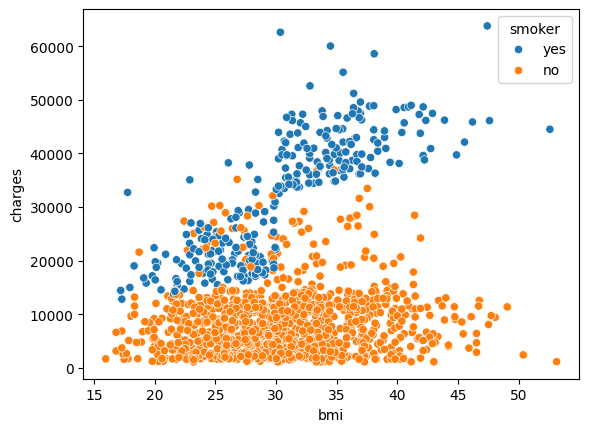

In [29]:
sns.scatterplot(
    x='bmi', 
    y='charges', 
    hue='smoker',
    data=df)
plt.show()

### Regression Plot Adds a trend line to show relationship strength.

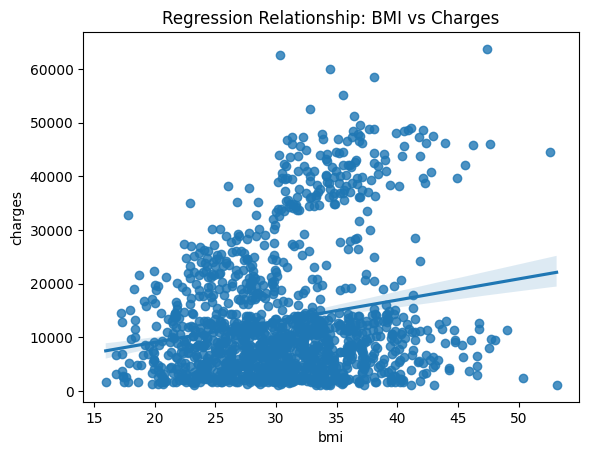

In [58]:
sns.regplot(
    x='bmi',
    y='charges',
    
    data=df
)

plt.title("Regression Relationship: BMI vs Charges")
plt.show()

### Impact of Smoking

### Smoking is the strongest predictor of insurance cost.

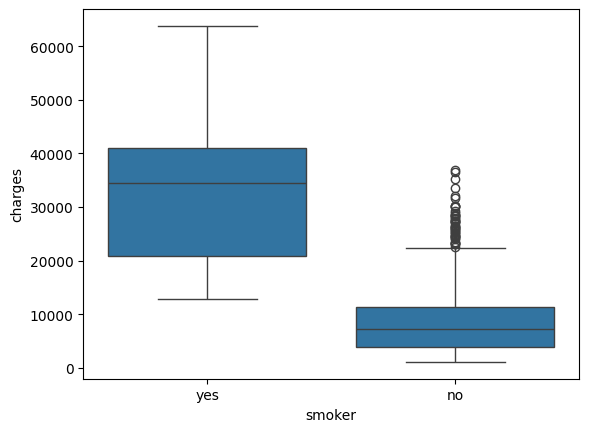

In [31]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

### Gender vs Charges

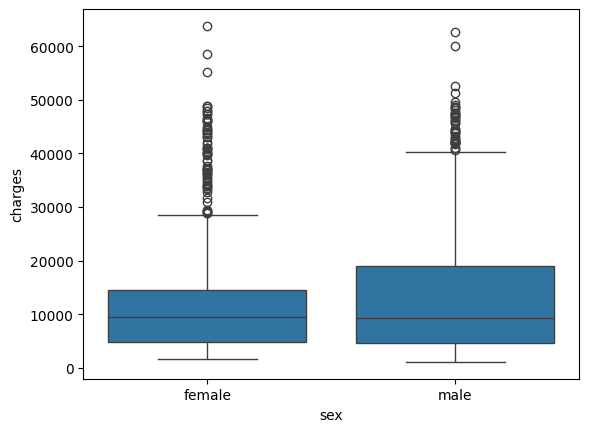

In [32]:
sns.boxplot(x='sex', y='charges', data=df)
plt.show()

### Region vs Charges

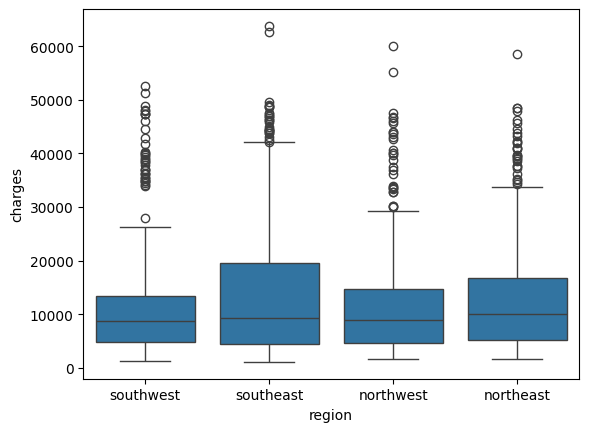

In [33]:
sns.boxplot(x='region', y='charges', data=df)
plt.show()

### Children vs Charges

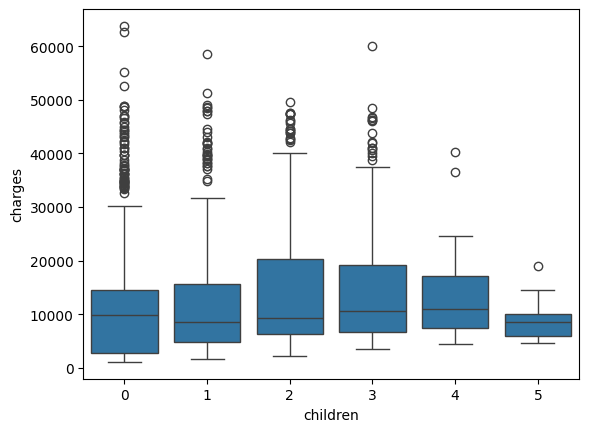

In [34]:
sns.boxplot(x='children', y='charges', data=df)
plt.show()

### Correlation Matrix

First convert categorical variables.

In [35]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


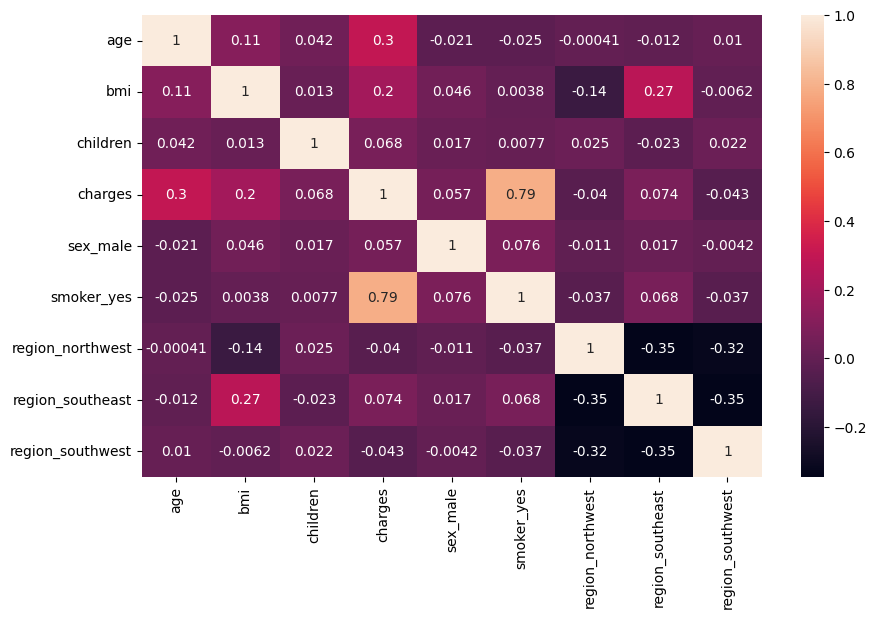

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True)
plt.show()

### Detect Outliers

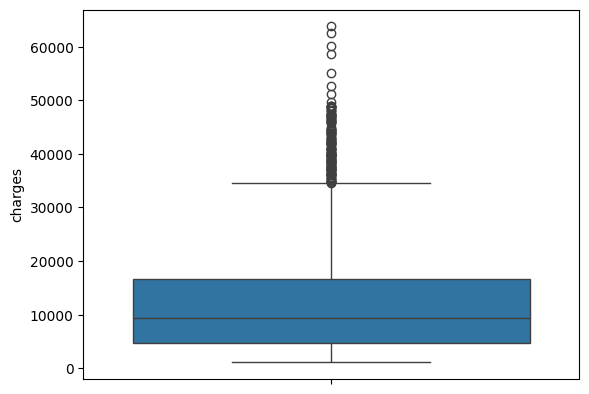

In [38]:
sns.boxplot(df['charges'])
plt.show()

### Final EDA Summary

Key insights:

Dataset contains 1338 records with 7 features.

No missing data.

Insurance charges are highly skewed.

Smoking has the biggest impact on medical cost.

Age and BMI show positive correlation with charges.

Gender and region have minimal impact.

Some high-cost outliers exist (mostly smokers).

### Feature Engineering

Machine learning models cannot handle categorical variables directly, so we encode them.

One-Hot Encoding

New columns created:
sex_male
smoker_yes
region_northwest
region_southeast
region_southwest

In [39]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### Define Features and Target

Features (X):
Target (y):


In [40]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

### Train Test Split

Typical split: 80% Training
20% Testing

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
X_train.shape
X_test.shape

(268, 8)

### 8. Train First Model (Linear Regression)

In [59]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred = lr.predict(X_test)

### 9. Model Evaluation
Mean Absolute Error:

Average prediction error




In [46]:
mae = mean_absolute_error(y_test, y_pred)
print(mae)

4181.194473753654


### Mean Squared Error

In [47]:
mse = mean_squared_error(y_test, y_pred)
print(mse)

33596915.85136146


### RMSE

In [48]:
rmse = np.sqrt(mse)
print(rmse)

5796.2846592762735


### R² Score (Most important)

In [49]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.7835929767120723


### Model explains about 78% variance in insurance charges.

# Train Better Model (Random Forest)

Tree-based models often perform better.

In [50]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
rf_pred = rf.predict(X_test)

### Evaluate Random Forest

In [52]:
r2_score(y_test, rf_pred)

0.8633194497365525

#### Random Forest predicts insurance cost better than Linear Regression.

### Feature Importance

This tells which variables impact prediction the most.

In [53]:
importance = rf.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
4        smoker_yes    0.606916
1               bmi    0.216221
0               age    0.135529
2          children    0.019672
3          sex_male    0.005957
5  region_northwest    0.005853
6  region_southeast    0.005586
7  region_southwest    0.004266


### Visualization of Feature Importance

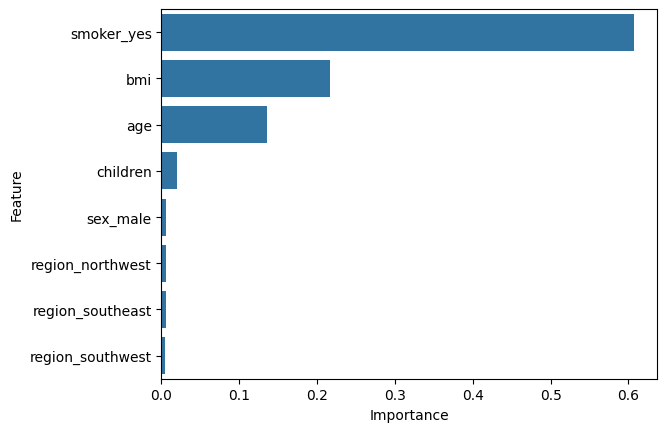

In [54]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.show()

### Final Model Performance Summary

### Table

| Model             | R² Score |
| ----------------- | -------- |
| Linear Regression | 0.78     |
| Random Forest     | 0.86     |


### Random Forest performs better because it captures nonlinear relationships.

### Final Project Workflow (Professional Pipeline)

Real-world ML pipeline:

1. Data Collection
2. Data Cleaning
3. EDA
4. Feature Engineering
5. Train/Test Split
6. Model Training
7. Model Evaluation
8. Hyperparameter Tuning
9. Model Deployment

# THE END